# S28B — Depth Sensitivity Sweep (execution sensitivity to placement depth Δ)
Single axis: Δ ∈ {1,5,20} ticks. queue_ahead, TTL, qty, lambda frozen. Layer A only (no PnL/economics).
Spec: OBSIDIAN/docs/superpowers/specs/2026-06-01-s28b-depth-sweep-design.md

In [1]:
# --- repo-root bootstrap ---
import sys, os
from pathlib import Path

_root = Path.cwd()
while not (_root / "research" / "__init__.py").exists() and _root != _root.parent:
    _root = _root.parent
if not (_root / "research" / "__init__.py").exists():
    raise RuntimeError("repo root not found: launch Jupyter from within the TRADING-BOT repo")
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("repo root:", _root)

repo root: C:\Users\Lenovo\Documents\TRADING-BOT


In [2]:
import json, hashlib
from pathlib import Path
from decimal import Decimal
import numpy as np, matplotlib.pyplot as plt
from research.experiments.het_sweep import (
    load_canonical_tape, run_depth_sweep, summarize_depth_sweep, reach_monotonicity_ok,
    DELTA_GRID_TICKS, QUEUE_FIXED_S28B, TTL_FROZEN_MS, LAMBDA_PER_SEC, SEED_EXPERIMENT, SIDE_SEED,
)

TAPE_PATH = "data/raw/BTCUSDT_AGGTRADES.csv"          # canonical tape (gate PASS, 41,544,041 rows)
OUT = Path("research/experiments/outputs"); OUT.mkdir(parents=True, exist_ok=True)

CONFIG = {"delta_ticks": DELTA_GRID_TICKS, "queue_fixed": str(QUEUE_FIXED_S28B),
          "order_qty": "0.01", "lambda_per_sec": LAMBDA_PER_SEC, "seed": SEED_EXPERIMENT,
          "ttl_ms": TTL_FROZEN_MS}
SPEC_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
print("SPEC_HASH:", SPEC_HASH)

SPEC_HASH: 9ec9405cf7cb


In [3]:
tape = load_canonical_tape(TAPE_PATH)
rows = run_depth_sweep(tape, DELTA_GRID_TICKS, QUEUE_FIXED_S28B, TTL_FROZEN_MS)
summary = summarize_depth_sweep(rows, DELTA_GRID_TICKS)

print(f"queue_ahead fixed = {QUEUE_FIXED_S28B} BTC   TTL = {TTL_FROZEN_MS/1000:.0f}s   orders/Δ ~ {len(rows)//len(DELTA_GRID_TICKS):,}")
print(f"{'Δ(t)':>5} {'reach':>7} {'cond_fill':>10} {'fill':>7} {'med_ttf(ms)':>12}")
for d in DELTA_GRID_TICKS:
    s = summary[d]
    print(f"{d:>5} {s['reach_rate']:>7.4f} {s['cond_fill']:>10.4f} {s['fill_rate']:>7.4f} {str(s['median_time_to_fill_ms']):>12}")

queue_ahead fixed = 5 BTC   TTL = 60s   orders/Δ ~ 86,148
 Δ(t)   reach  cond_fill    fill  med_ttf(ms)
    1  0.8682     0.6983  0.6063      16622.5
    5  0.7527     0.7457  0.5613      18626.0
   20  0.7299     0.7353  0.5367      19185.5


In [4]:
# (1) Replication invariant: the (Δ=5t, q=5) cell must reproduce S28A's TRIPLE (within tolerance).
S28A_REF = {"reach": 0.753, "fill": 0.5613, "ttf_ms": 18626.0}
TOL = {"reach": 0.01, "fill": 0.01, "ttf_ms": 1000.0}
s5 = summary[5]
checks = {
    "reach": abs(s5["reach_rate"] - S28A_REF["reach"]) <= TOL["reach"],
    "fill":  abs(s5["fill_rate"] - S28A_REF["fill"])   <= TOL["fill"],
    "ttf_ms": (s5["median_time_to_fill_ms"] is not None
               and abs(s5["median_time_to_fill_ms"] - S28A_REF["ttf_ms"]) <= TOL["ttf_ms"]),
}
print("REPLICATION (Δ=5t, q=5) vs S28A:", checks)
assert all(checks.values()), f"REPLICATION FAILED — likely a bug in per-Δ regeneration: {checks}"

# (2) reach monotonicity — reported alarm, NOT a PASS/FAIL gate.
if reach_monotonicity_ok(summary, DELTA_GRID_TICKS):
    print("SANITY ok: reach(Δ) is non-increasing in depth.")
else:
    print("⚠️ ALARM: reach(Δ) is NOT monotone non-increasing — bug OR an extremely interesting finding. Investigate.")

REPLICATION (Δ=5t, q=5) vs S28A: {'reach': True, 'fill': True, 'ttf_ms': True}
SANITY ok: reach(Δ) is non-increasing in depth.


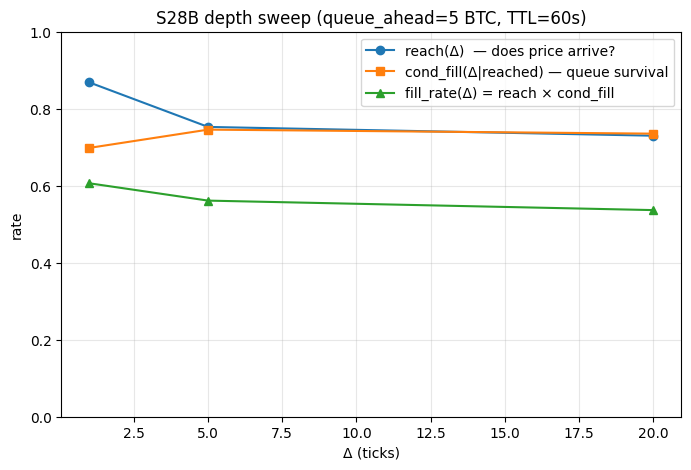

In [5]:
ds = DELTA_GRID_TICKS
reach = [summary[d]["reach_rate"] for d in ds]
cond  = [summary[d]["cond_fill"] for d in ds]
fill  = [summary[d]["fill_rate"] for d in ds]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ds, reach, marker="o", label="reach(Δ)  — does price arrive?")
ax.plot(ds, cond,  marker="s", label="cond_fill(Δ|reached) — queue survival")
ax.plot(ds, fill,  marker="^", label="fill_rate(Δ) = reach × cond_fill")
ax.set_xlabel("Δ (ticks)"); ax.set_ylabel("rate"); ax.set_ylim(0, 1)
ax.set_title(f"S28B depth sweep (queue_ahead={QUEUE_FIXED_S28B} BTC, TTL={TTL_FROZEN_MS/1000:.0f}s)")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(OUT / f"S28B_depth_curves_{SPEC_HASH}.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
import csv
serial = {str(d): summary[d] for d in DELTA_GRID_TICKS}
for v in serial.values():
    for k in ("reach_ci", "cond_fill_ci", "fill_rate_ci"):
        v[k] = list(v[k])
(OUT / f"S28B_summary_{SPEC_HASH}.json").write_text(
    json.dumps({"config": CONFIG, "spec_hash": SPEC_HASH, "summary": serial}, indent=2), encoding="utf-8")

with open(OUT / f"S28B_rows_{SPEC_HASH}.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["delta_ticks", "arrival_ts", "filled", "time_to_fill_ms", "reached",
                "queue_consumed", "queue_remaining", "through_volume"])
    for r in rows:
        w.writerow([r["delta_ticks"], r["arrival_ts"], r["filled"], r["time_to_fill_ms"],
                    r["reached"], str(r["queue_consumed"]), str(r["queue_remaining"]), str(r["through_volume"])])
print("FROZEN artifacts written with SPEC_HASH", SPEC_HASH)

Read the table directly (the verdict — elasticity is secondary color):
- If fill_rate(Δ) drops from Δ=5→20 comparably-or-more than fill dropped from queue=5→50 in S28A (0.561→0.140), depth is at least as material as the queue.
- Decomposition localizes the Hidden Execution Tax: reach↓ = "never arrives" (depth axis); cond_fill↓ = "queue too deep" (queue axis).
After S28B: EVALUATION PAUSE before S28C (A+B may already cover a v1 operational model). NO PnL/economics here (Layer B, deferred).